In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *
from warpPlot import *

# This library
from warpSPH import *

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
from utils import *
from warpSPH.io import *

In [3]:
# For the dataset we want to wrap everything in an easy to use class.
#
# The input to the dataset is a dataclass that contains the dataset parameters:
# - The folder where the dataset is stored
# - The name of the dataset
# - The number of history frames to use for the input. 0 means only the current frame is used. 1 means the current frame and the previous frame are used, etc.
# - The number of trajectory frames to use for the output. 0 means only the next frame is used.
# - Temporal downsampling factor. 1 means use every frame, 2 means use every other frame, etc.
# - Cutoff initialization length. The number of frames to skip at the beginning of the dataset. This is useful for datasets that have a long initialization phase.
# - Cutoff final length. The number of frames to skip at the end of the dataset. This is useful for datasets that have a long finalization phase.
#
# The dataset then loads the data from the folder using all h5 and hdf5 files in the folder. 
# It then creates a list of all the frames in the dataset, and then creates a list of all the valid indices for the dataset based on the history and trajectory lengths, as well as the downsampling factor and cutoff lengths.
# This means we can use len(dataset) to get the number of valid samples in the dataset, and dataset[i] to get the i-th sample.
# The dataset can then be queried to get the i-th sample which will return a dictionary containing:
# - Static particle data
#     = Particle Masses
#     = Particle Kinds
#     = Particle Supports
#     = Particle UIDs
#     = Particle Materials
#     = Particle Normals (for boundary particles)
# - Simulation metadata
#     = Simulation time
#     = Simulation timestep (both actual and the one loaded from the h5 file based on the coarse graining and exported timestep)
#     = Number of particles, fluid and boundary separately and combined
#     = The target number of neighbors for the SPH kernel
#     = The time integrator used for the simulation
#     = Domain bounds (min, max, periodicity)
#     = Free surface flag
#     = Shifting active flag
#     = Gravity flag, vector and magnitude
#     = The fluid speed of sound
#     = The fluid viscosity (nu)
#     = The h5 file this was loaded from
#     = The frame index in the h5 file this was loaded from
#     = The freestream velocity and flag if it is active as well as the forcingWidth
#     = The kolmogorov length scale and flag if it is active
# - Dynamic input particle data for the history frames
#     = Particle Positions (shape: [history_length, num_particles, dim])
#     = Particle Velocities (shape: [history_length, num_particles, dim])
#     = Particle Densities (shape: [history_length, num_particles])
# - Dynamic input particle data for the current frame
#     = Particle Positions (shape: [num_particles, dim])
#     = Particle Velocities (shape: [num_particles, dim])
#     = Particle Densities (shape: [num_particles])
# - Dynamic output particle data for the trajectory frames
#     = Particle Positions (shape: [trajectory_length, num_particles, dim])
#     = Particle Velocities (shape: [trajectory_length, num_particles, dim])
#     = Particle Densities (shape: [trajectory_length, num_particles])
#
# Because every simulation can have different particle counts and different domain sizes and boundary conditions, batch processing is not (really) possible. The preferred alternative is to use gradient accumulation over multiple samples and just eating the computational overhead. However, as most networks are memory limited even on single samples, this is not a big deal. The dataset can be used with a PyTorch DataLoader to provide multi-threaded loading of the data, but the DataLoader will not be able to batch the data due to the variable particle counts and domain sizes. The DataLoader will still be useful for shuffling the data and providing multi-threaded loading of the data.
# 
# Note that it is possible to restore the SimulationSystem from this data and we provide a function to do so. 
# Restoring the full simulation state requires re-assembling the config, which is possible as well, but not done by default. This can be achieved by using the h5 file and frame index to load the config from the original simulation. The SimulationSystem can then be restored by using the config and the dynamic input particle data for the history frames and current frame.

In [4]:
from dataclasses import dataclass, field

@dataclass
class DatasetParams:
    folder: str = field(default_factory=str)
    name: str = field(default_factory=str)
    history_length: int = 0
    trajectory_length: int = 0
    downsample_factor: int = 1
    cutoff_init: int = 0
    cutoff_final: int = 0

In [10]:
import h5py
from pathlib import Path


class SPHDataset(torch.utils.data.Dataset):
    def __init__(self, params: DatasetParams):
        super().__init__()
        self.params = params
        self.folder = Path(params.folder)
        self.name = params.name if params.name else self.folder.name
        self.history_length = int(params.history_length)
        self.trajectory_length = int(params.trajectory_length)
        self.downsample_factor = max(1, int(params.downsample_factor))
        self.cutoff_init = max(0, int(params.cutoff_init))
        self.cutoff_final = max(0, int(params.cutoff_final))

        if not self.folder.exists():
            raise FileNotFoundError(f"Dataset folder does not exist: {self.folder}")

        self.simulation_files = sorted(
            [
                str(self.folder / fn)
                for fn in os.listdir(self.folder)
                if fn.endswith(".h5") or fn.endswith(".hdf5")
            ]
        )

        if len(self.simulation_files) == 0:
            raise RuntimeError(f"No .h5/.hdf5 files found in {self.folder}")

        self._future_length = max(1, self.trajectory_length)
        self._file_info = []
        self.valid_indices = []

        for file_idx, file_path in enumerate(self.simulation_files):
            info = self._scan_file(file_path)
            self._file_info.append(info)
            self.valid_indices.extend(
                [(file_idx, frame_idx) for frame_idx in info["valid_frame_indices"]]
            )

        if len(self.valid_indices) == 0:
            raise RuntimeError(
                "No valid dataset samples found. Check history/trajectory/downsample/cutoff settings."
            )

        print(
            f"[{self.name}] Loaded {len(self.simulation_files)} files with {len(self.valid_indices)} samples "
            f"(history={self.history_length}, future={self._future_length}, downsample={self.downsample_factor})"
        )

    def _scan_file(self, file_path: str):
        with h5py.File(file_path, "r") as f:
            frame_keys = {}
            for key in ["positions", "velocities", "densities", "times"]:
                if key in f and self._is_group(f, key):
                    keys = list(f[key].keys())
                    keys = sorted(keys, key=self._frame_key_sort_key)
                    frame_keys[key] = keys

            num_frames = self._num_frames(f, frame_keys)

            first_valid = self.cutoff_init + self.history_length * self.downsample_factor
            last_valid = (
                num_frames
                - 1
                - self.cutoff_final
                - self._future_length * self.downsample_factor
            )

            if last_valid < first_valid:
                valid = []
            else:
                valid = list(range(first_valid, last_valid + 1))

            return {
                "path": file_path,
                "num_frames": num_frames,
                "valid_frame_indices": valid,
                "frame_keys": frame_keys,
            }

    @staticmethod
    def _is_group(f: h5py.File, key: str) -> bool:
        return isinstance(f[key], h5py.Group)

    @staticmethod
    def _frame_key_sort_key(key: str):
        # Supports keys like frame_00012 or plain numeric keys.
        if "_" in key:
            tail = key.split("_")[-1]
            if tail.isdigit():
                return int(tail)
        if key.isdigit():
            return int(key)
        return key

    def _num_frames(self, f: h5py.File, frame_keys: dict) -> int:
        if self._is_group(f, "positions"):
            return len(frame_keys.get("positions", []))
        return int(f["positions"].shape[0])

    def _read_frame_array(self, f: h5py.File, key: str, frame_idx: int, file_info: dict):
        if self._is_group(f, key):
            keys = file_info["frame_keys"].get(key, [])
            if frame_idx < 0 or frame_idx >= len(keys):
                raise IndexError(f"Frame index {frame_idx} out of range for key '{key}'")
            return f[key][keys[frame_idx]][:]
        return f[key][frame_idx][:]

    def _read_frame_time(self, f: h5py.File, frame_idx: int, file_info: dict) -> float:
        if "times" not in f:
            return float("nan")
        if self._is_group(f, "times"):
            keys = file_info["frame_keys"].get("times", [])
            if frame_idx < 0 or frame_idx >= len(keys):
                return float("nan")
            return float(f["times"][keys[frame_idx]][:].item())
        return float(f["times"][frame_idx].item())

    def __len__(self):
        return len(self.valid_indices)

    def _read_static(self, f: h5py.File):
        out = {}
        for key in [
            "combinedMasses",
            "combinedKinds",
            "combinedSupports",
            "combinedUIDs",
            "combinedMaterials",
            "combinedGhostIndices",
            "combinedGhostOffsets",
            "boundaryPositions",
            "boundaryMasses",
            "boundarySupports",
            "boundaryUIDs",
            "boundaryKinds",
            "boundaryGhostOffsets",
            "boundaryOffsets",
            "ghostPositions",
            "ghostMasses",
            "ghostSupports",
            "ghostUIDs",
            "ghostKinds",
        ]:
            if key in f:
                arr = f[key][:]
                if np.issubdtype(arr.dtype, np.integer):
                    out[key] = torch.as_tensor(arr, dtype=torch.int64)
                else:
                    out[key] = torch.as_tensor(arr, dtype=torch.float32)
        return out

    def _read_metadata(self, f: h5py.File, frame_idx: int, file_path: str, file_info: dict):
        meta = {
            "h5_file": file_path,
            "frame_index": int(frame_idx),
            "time": self._read_frame_time(f, frame_idx, file_info),
            "dt_simulation": float(f.attrs["original_dt"]) if "original_dt" in f.attrs else float("nan"),
            "dt_export": float(f.attrs["exportInterval"]) if "exportInterval" in f.attrs else float("nan"),
            "num_particles": int(f["combinedPositions"].shape[0]) if "combinedPositions" in f else int(self._read_frame_array(f, "positions", frame_idx, file_info).shape[0]),
            "num_fluid_particles": int((f["combinedKinds"][:] == 0).sum()) if "combinedKinds" in f else -1,
            "num_boundary_particles": int((f["combinedKinds"][:] == 1).sum()) if "combinedKinds" in f else -1,
        }

        attr_keys = [
            "caseName",
            "scheme",
            "targetNeighbors",
            "L",
            "W",
            "nx",
            "n_h",
            "timeLimit",
            "obstacleType",
            "obstacleActive",
            "aoa",
            "enableFreeSurface",
            "enableShifting",
            "gravityActive",
            "freeStreamVelocity",
            "enableFreeStream",
            "forcingWidth",
            "kolmogorovLengthScale",
            "enableKolmogorovForcing",
            "kolmogorovForcingAmplitude",
            "kolmogorovForcingWavenumber",
        ]
        for key in attr_keys:
            if key in f.attrs:
                value = f.attrs[key]
                if isinstance(value, np.ndarray):
                    meta[key] = value.tolist()
                elif isinstance(value, np.generic):
                    meta[key] = value.item()
                else:
                    meta[key] = value

        if "config" in f:
            try:
                meta["restored_config"] = restoreConfig_from_h5(f["config"])
            except Exception:
                meta["restored_config"] = None

        return meta

    def __getitem__(self, idx: int):
        file_idx, frame_idx = self.valid_indices[idx]
        file_path = self.simulation_files[file_idx]
        file_info = self._file_info[file_idx]

        with h5py.File(file_path, "r") as f:
            history_frames = [
                frame_idx - (self.history_length - h) * self.downsample_factor
                for h in range(self.history_length)
            ]

            history_positions = []
            history_velocities = []
            history_densities = []
            for hf in history_frames:
                history_positions.append(self._read_frame_array(f, "positions", hf, file_info))
                history_velocities.append(self._read_frame_array(f, "velocities", hf, file_info))
                history_densities.append(self._read_frame_array(f, "densities", hf, file_info))

            current_positions = self._read_frame_array(f, "positions", frame_idx, file_info)
            current_velocities = self._read_frame_array(f, "velocities", frame_idx, file_info)
            current_densities = self._read_frame_array(f, "densities", frame_idx, file_info)

            trajectory_positions = []
            trajectory_velocities = []
            trajectory_densities = []
            for t in range(1, self._future_length + 1):
                tf = frame_idx + t * self.downsample_factor
                trajectory_positions.append(self._read_frame_array(f, "positions", tf, file_info))
                trajectory_velocities.append(self._read_frame_array(f, "velocities", tf, file_info))
                trajectory_densities.append(self._read_frame_array(f, "densities", tf, file_info))

            history_positions_t = (
                torch.as_tensor(np.stack(history_positions, axis=0), dtype=torch.float32)
                if len(history_positions) > 0
                else torch.empty((0,) + current_positions.shape, dtype=torch.float32)
            )
            history_velocities_t = (
                torch.as_tensor(np.stack(history_velocities, axis=0), dtype=torch.float32)
                if len(history_velocities) > 0
                else torch.empty((0,) + current_velocities.shape, dtype=torch.float32)
            )
            history_densities_t = (
                torch.as_tensor(np.stack(history_densities, axis=0), dtype=torch.float32)
                if len(history_densities) > 0
                else torch.empty((0,) + current_densities.shape, dtype=torch.float32)
            )

            sample = {
                "static": self._read_static(f),
                "metadata": self._read_metadata(f, frame_idx, file_path, file_info),
                "input_history": {
                    "positions": history_positions_t,
                    "velocities": history_velocities_t,
                    "densities": history_densities_t,
                },
                "input_current": {
                    "positions": torch.as_tensor(current_positions, dtype=torch.float32),
                    "velocities": torch.as_tensor(current_velocities, dtype=torch.float32),
                    "densities": torch.as_tensor(current_densities, dtype=torch.float32),
                },
                "target_trajectory": {
                    "positions": torch.as_tensor(np.stack(trajectory_positions, axis=0), dtype=torch.float32),
                    "velocities": torch.as_tensor(np.stack(trajectory_velocities, axis=0), dtype=torch.float32),
                    "densities": torch.as_tensor(np.stack(trajectory_densities, axis=0), dtype=torch.float32),
                },
            }

            return sample

    def restore_state(self, sample_or_index, remove_ghost: bool = True, device: str | torch.device | None = None):
        if isinstance(sample_or_index, int):
            sample = self[sample_or_index]
        else:
            sample = sample_or_index

        meta = sample["metadata"]
        file_path = meta["h5_file"]
        frame_idx = int(meta["frame_index"])

        restored_config = meta.get("restored_config")
        if restored_config is None:
            raise RuntimeError("No restored config is available in the sample metadata.")

        scheme = restored_config["scheme"]
        scheme_enum = schemeNameToSimulationScheme(scheme)
        _, _, _, _, _, _, import_fn = buildScheme(scheme_enum)
        config = dictToConfig(restored_config["config"])
        _ = import_fn(restored_config["schemeConfig"])

        state_device = torch.device(config.device if device is None else device)

        file_idx, _ = self.valid_indices[sample_or_index] if isinstance(sample_or_index, int) else (None, None)
        if file_idx is None:
            file_idx = self.simulation_files.index(file_path)
        file_info = self._file_info[file_idx]

        with h5py.File(file_path, "r") as f:
            kinds_np = f["combinedKinds"][:]
            if remove_ghost:
                mask = kinds_np != 2
            else:
                mask = np.ones_like(kinds_np, dtype=bool)

            pos = self._read_frame_array(f, "positions", frame_idx, file_info)[mask]
            vel = self._read_frame_array(f, "velocities", frame_idx, file_info)[mask]
            rho = self._read_frame_array(f, "densities", frame_idx, file_info)[mask]

            state = WeaklyCompressibleState(
                positions=torch.as_tensor(pos, dtype=torch.float32, device=state_device),
                supports=torch.as_tensor(f["combinedSupports"][:][mask], dtype=torch.float32, device=state_device),
                masses=torch.as_tensor(f["combinedMasses"][:][mask], dtype=torch.float32, device=state_device),
                densities=torch.as_tensor(rho, dtype=torch.float32, device=state_device),
                velocities=torch.as_tensor(vel, dtype=torch.float32, device=state_device),
                pressures=None,
                soundspeeds=None,
                kinds=torch.as_tensor(f["combinedKinds"][:][mask], dtype=torch.int32, device=state_device),
                materials=torch.as_tensor(f["combinedMaterials"][:][mask], dtype=torch.int32, device=state_device),
                UIDs=torch.as_tensor(f["combinedUIDs"][:][mask], dtype=torch.int64, device=state_device),
                UIDcounter=int(np.sum(mask)),
                ghostIndices=(
                    torch.as_tensor(f["combinedGhostIndices"][:][mask], dtype=torch.int32, device=state_device)
                    if "combinedGhostIndices" in f else None
                ),
                ghostOffsets=(
                    torch.as_tensor(f["combinedGhostOffsets"][:][mask], dtype=torch.float32, device=state_device)
                    if "combinedGhostOffsets" in f else None
                ),
            )

        return state, config

In [11]:
def sph_collate_variable(batch):
    # Keep a list because particle counts can differ across samples.
    return batch


dataset_params = DatasetParams(
    folder="./compressed",
    name="weakly-compressible-compressed",
    history_length=2,
    trajectory_length=4,
    downsample_factor=1,
    cutoff_init=0,
    cutoff_final=0,
 )

dataset = SPHDataset(dataset_params)
loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    collate_fn=sph_collate_variable,
 )

first_batch = next(iter(loader))
first_sample = first_batch[0]

print(f"dataset samples: {len(dataset)}")
print("history positions shape:", tuple(first_sample["input_history"]["positions"].shape))
print("current positions shape:", tuple(first_sample["input_current"]["positions"].shape))
print("target positions shape:", tuple(first_sample["target_trajectory"]["positions"].shape))
print("source:", first_sample["metadata"]["h5_file"], "frame", first_sample["metadata"]["frame_index"])

[weakly-compressible-compressed] Loaded 9 files with 11946 samples (history=2, future=4, downsample=1)
dataset samples: 11946
history positions shape: (2, 68764, 2)
current positions shape: (68764, 2)
target positions shape: (4, 68764, 2)
source: compressed/trajectory_kolmogorov_wObstacle_2026-07-30_22-47-58_256_4_2.0_2.0_obstacle_0.5_0_0.hdf5 frame 343


In [12]:
sample = dataset[0]
restored_state, restored_config = dataset.restore_state(sample, remove_ghost=True)

print("restored state positions:", tuple(restored_state.positions.shape))
print("restored state velocities:", tuple(restored_state.velocities.shape))
print("restored config device:", restored_config.device)

restored state positions: (65536, 2)
restored state velocities: (65536, 2)
restored config device: cuda:0


In [19]:
from ipywidgets import widgets
from IPython.display import display

# Build defaults if this cell is run standalone.
if "dataset" not in globals():
    dataset_params = DatasetParams(
        folder="./compressed",
        name="weakly-compressible-compressed",
        history_length=2,
        trajectory_length=4,
        downsample_factor=1,
        cutoff_init=0,
        cutoff_final=0,
    )
    dataset = SPHDataset(dataset_params)


def _sample_to_state(sample, remove_ghost=True, device="cpu"):
    static = sample["static"]
    pos = sample["input_current"]["positions"]
    vel = sample["input_current"]["velocities"]
    rho = sample["input_current"]["densities"]

    kinds_all = static["combinedKinds"].to(torch.int32)
    if remove_ghost:
        mask = kinds_all != 2
    else:
        mask = torch.ones_like(kinds_all, dtype=torch.bool)

    state = WeaklyCompressibleState(
        positions=pos[mask].to(torch.float32).to(device),
        supports=static["combinedSupports"][mask].to(torch.float32).to(device),
        masses=static["combinedMasses"][mask].to(torch.float32).to(device),
        densities=rho[mask].to(torch.float32).to(device),
        velocities=vel[mask].to(torch.float32).to(device),
        pressures=None,
        soundspeeds=None,
        kinds=static["combinedKinds"][mask].to(torch.int32).to(device),
        materials=static["combinedMaterials"][mask].to(torch.int32).to(device),
        UIDs=static["combinedUIDs"][mask].to(torch.int64).to(device),
        UIDcounter=int(mask.sum().item()),
        ghostIndices=(
            static["combinedGhostIndices"][mask].to(torch.int32).to(device)
            if "combinedGhostIndices" in static else None
        ),
        ghostOffsets=(
            static["combinedGhostOffsets"][mask].to(torch.float32).to(device)
            if "combinedGhostOffsets" in static else None
        ),
    )
    return state


def _sample_to_domain(sample, device="cpu"):
    restored = sample["metadata"].get("restored_config")
    if restored is None:
        return None
    cfg = dictToConfig(restored["config"] )
    cfg.domain.min = cfg.domain.min.to(device)
    cfg.domain.max = cfg.domain.max.to(device)
    return cfg.domain


def _title_from_sample(sample, idx, total):
    meta = sample["metadata"]
    h5_file = os.path.basename(meta["h5_file"])
    frame = int(meta["frame_index"])
    t = meta.get("time", float("nan"))
    dt_sim = meta.get("dt_simulation", float("nan"))
    dt_exp = meta.get("dt_export", float("nan"))
    case_name = meta.get("caseName", "unknown")
    nf = meta.get("num_fluid_particles", -1)
    nb = meta.get("num_boundary_particles", -1)
    return (
        f"Dataset sample {idx+1}/{total} | case={case_name} | source={h5_file} | frame={frame}\n"
        f"t={t:.5g} | dt={dt_sim:.5g} | export_dt={dt_exp:.5g} | particles={nf} fluid + {nb} boundary"
    )


scrub_device = "cpu"
scrub_remove_ghost = True
initial_idx = 0
initial_sample = dataset[initial_idx]
initial_state = _sample_to_state(initial_sample, remove_ghost=scrub_remove_ghost, device=scrub_device)
initial_domain = _sample_to_domain(initial_sample, device=scrub_device)

marker_size = 3
uid_plot = PlottingOptions(
    colorMap=CyclicColorMap.twilight,
    markerSize=marker_size,
    quantityScaling=PlotScaling.Linear,
    plotTitle="Particle IDs",
    boundaryVisualization=VisualizeOptions.Passive,
    plotTitleGap=0.08,
    plotDomain=True,
 )

velx_plot = PlottingOptions(
    colorMap=DivergingColorMap.RdBu,
    flipColorMap=False,
    markerSize=marker_size,
    midPoint=0.0,
    quantityScaling=PlotScaling.Linear,
    plotTitle="Velocity X",
    boundaryVisualization=VisualizeOptions.Visualize,
    plotTitleGap=0.08,
 )

vely_plot = PlottingOptions(
    colorMap=DivergingColorMap.RdBu,
    flipColorMap=False,
    markerSize=marker_size,
    midPoint=0.0,
    quantityScaling=PlotScaling.Linear,
    plotTitle="Velocity Y",
    boundaryVisualization=VisualizeOptions.Visualize,
    plotTitleGap=0.08,
 )

velmag_plot = PlottingOptions(
    colorMap=UniformColorMap.viridis,
    markerSize=marker_size,
    quantityScaling=PlotScaling.Linear,
    plotTitle="Velocity Magnitude",
    boundaryVisualization=VisualizeOptions.Visualize,
    plotTitleGap=0.08,
 )

den_plot = PlottingOptions(
    colorMap=DivergingColorMap.RdBu,
    flipColorMap=True,
    markerSize=marker_size,
    midPoint=1.0,
    quantityScaling=PlotScaling.Linear,
    plotTitle="Density",
    plotTitleGap=0.08,
 )

quantity_dropdown = widgets.Dropdown(
    options=[
        ("UID", "uid"),
        ("Velocity X", "velx"),
        ("Velocity Y", "vely"),
        ("Velocity |v|", "velmag"),
        ("Density", "rho"),
    ],
    value="uid",
    description="Quantity:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="45%"),
 )

sample_slider = widgets.IntSlider(
    value=initial_idx,
    min=0,
    max=len(dataset)-1,
    step=1,
    description="Dataset sample:",
    continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="80%"),
 )

sample_play = widgets.Play(
    value=initial_idx,
    min=0,
    max=len(dataset)-1,
    step=1,
    interval=75,
    description="Play",
 )
widgets.jslink((sample_play, "value"), (sample_slider, "value"))

def _make_plot_payload(state, q_mode):
    if q_mode == "velx":
        return {"A": state.velocities[:, 0]}, {"A": velx_plot}
    if q_mode == "vely":
        if state.velocities.shape[1] < 2:
            return {"A": state.velocities[:, 0] * 0.0}, {"A": vely_plot}
        return {"A": state.velocities[:, 1]}, {"A": vely_plot}
    if q_mode == "velmag":
        velmag = torch.linalg.norm(state.velocities, dim=1)
        return {"A": velmag}, {"A": velmag_plot}
    if q_mode == "rho":
        return {"A": state.densities}, {"A": den_plot}
    return {"A": state.UIDs}, {"A": uid_plot}

initial_quantities, initial_options = _make_plot_payload(initial_state, quantity_dropdown.value)
sample_plotter = visualize(
    particleState=initial_state,
    domain=initial_domain,
    quantities=initial_quantities,
    plotOptions=initial_options,
    figTitle="Dataset Scrubber",
    mosaic="A",
    figsize=(12, 8),
    backend="vispy",
 )
sample_plotter.updateTitle(_title_from_sample(initial_sample, initial_idx, len(dataset)))

def _update_sample(idx):
    sample = dataset[int(idx)]
    state = _sample_to_state(sample, remove_ghost=scrub_remove_ghost, device=scrub_device)
    domain = _sample_to_domain(sample, device=scrub_device)
    quantities, _ = _make_plot_payload(state, quantity_dropdown.value)
    sample_plotter.updateQuantities(
        quantities,
        newParticleState=state,
        newDomain=domain,
    )
    sample_plotter.updateTitle(_title_from_sample(sample, int(idx), len(dataset)))

def _on_slider(change):
    if change["name"] == "value":
        _update_sample(change["new"])

def _on_quantity_change(change):
    if change["name"] == "value":
        _update_sample(sample_slider.value)

sample_slider.observe(_on_slider, names="value")
quantity_dropdown.observe(_on_quantity_change, names="value")

display(widgets.HBox([sample_play, quantity_dropdown]))
display(sample_slider)

RFBOutputContext()

IntSlider(value=0, continuous_update=False, description='Dataset sample:', layout=Layout(width='80%'), max=119…

In [20]:
# Quick smoke test for scrubber updates without plot rebuilds.
_update_sample(min(10, len(dataset)-1))
quantity_dropdown.value = "velx"
_update_sample(sample_slider.value)
quantity_dropdown.value = "vely"
_update_sample(sample_slider.value)
quantity_dropdown.value = "velmag"
_update_sample(sample_slider.value)
quantity_dropdown.value = "rho"
_update_sample(sample_slider.value)
print("Scrubber update + velocity component mode test passed.")

Scrubber update + velocity component mode test passed.


In [9]:
directory = f'./compressed/'

simulations = os.listdir(directory)
simulations = [sim for sim in simulations if 'h5' in sim or 'hdf5' in sim]


print(f'Found {len(simulations)} simulations in {directory}')
# trajectoryFile = f'{directory}/trajectory.h5'
# configFile = f'{directory}/config.json'

Found 9 simulations in ./compressed/


In [10]:
def getTitleString(trajectory, schemeConfig, state, time):
    caseName = trajectory.attrs['caseName']
    timeLimit = trajectory.attrs['timeLimit']
    simulationDt = trajectory.attrs['original_dt']
    exportDt = trajectory.attrs['exportInterval']
    L = trajectory.attrs['L']
    W = trajectory.attrs['W']
    obstacleType = trajectory.attrs['obstacleType']
    obstacleActive = trajectory.attrs['obstacleActive']
    aoa = trajectory.attrs['aoa']
    nx = trajectory.attrs['nx']
    n_h = trajectory.attrs['n_h']
    fixedSoundSpeed = schemeConfig.fluid.fixedSoundSpeed

    caseText = f'{caseName}'
    timeText = f't = {time:.4g}/{timeLimit:.4g} | dt = {simulationDt:.4g} / export dt = {exportDt:.4g}'
    particleText = f'particles = {len(state.positions[state.kinds == 0])} fluid + {len(state.positions[state.kinds == 1])} boundary | nx = {nx} | n_h = {n_h}'
    domainText = f'L = {L}, W = {W}'
    obstacleText = f'obstacle: {obstacleType}, aoa: {aoa}' if obstacleActive else 'no obstacle'
    stateText = f'v_max = {state.velocities.max().cpu().item():.4g} (c0 = {fixedSoundSpeed:.4g}), rho_max = {state.densities.max().cpu().item():.4g}, rho_min = {state.densities.min().cpu().item():.4g}'


    titleString = f'{caseText} | {timeText} | {particleText}\n{domainText} | {obstacleText} | {stateText}'
    return titleString

markerSize = 6
velocityPlot = PlottingOptions(
    colorMap = UniformColorMap.viridis,
    markerSize = markerSize,
    midPoint = 0.0,
    quantityScaling = PlotScaling.Linear,
    mapping = Mapping.L2Norm,
    plotTitle = "Particle Velocity Magnitude",
    plotTitleGap = 0.08,
    boundaryVisualization = VisualizeOptions.Visualize,
    # gridVisualization = GridVisualization(
    #     resolution = 1024,
    #     streamLines = True,
    # ),

    # vMin=1e-10,
    vMin = 0.0,
    vMax = 2.7,
)
densityPlot = PlottingOptions(
    colorMap = DivergingColorMap.RdBu,
    flipColorMap=True,
    markerSize = markerSize,
    midPoint = 1.0,
    quantityScaling = PlotScaling.Linear,
    plotTitle = "Particle Density",
    # vMin = 0.95,
    # vMax = 1.05,
    plotTitleGap = 0.08,
    # gridVisualization = GridVisualization(
    #     resolution = 512,
    # ),
)
UIDPlot = PlottingOptions(
    colorMap = CyclicColorMap.twilight,
    # flipColorMap=True,
    markerSize = markerSize,
    # midPoint = 1.0,
    quantityScaling = PlotScaling.Linear,
    plotTitle = f"Particle IDs",
    boundaryVisualization = VisualizeOptions.Passive,
    # vMin = 0.95,
    # vMax = 1.05
    plotTitleGap = 0.08,
    # gridVisualization = GridVisualization(
    #     resolution = 512,
    # ),
    plotDomain = True
)


In [11]:
import h5py
import json

print(f'Found {len(simulations)} simulations in {directory}')
file = simulations[0]

trajectoryFile = f'{directory}/{file}'
print(f'Loading trajectory from {trajectoryFile}')

# loadedConfig = json.load(open(configFile, 'r'))

def loadTrajectory(trajectoryFile):

    trajectory = h5py.File(trajectoryFile, 'r')
    numStates = trajectory['positions'].shape[0] if not isinstance(trajectory['positions'], h5py.Group) else len(trajectory['positions'].keys())
    numFluidParticles = trajectory['positions'].shape[1] if not isinstance(trajectory['positions'], h5py.Group) else len(trajectory['positions'][f'frame_{0:05d}'][:])
    print(f'Loaded trajectory with {numStates} states and {numFluidParticles} fluid particles from {trajectoryFile}')

    restoredConfig = restoreConfig_from_h5(trajectory['config'])

    scheme = restoredConfig['scheme']
    schemeEnum = schemeNameToSimulationScheme(scheme)

    SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(schemeEnum)
    config, schemeConfig = dictToConfig(restoredConfig['config']), import_fn(restoredConfig['schemeConfig'])

    device = torch.device(config.device)
    kinds = torch.tensor(trajectory['combinedKinds'][:], dtype=torch.int32)

    simulationState = WeaklyCompressibleState(
        positions = torch.tensor(trajectory['combinedPositions'][:], dtype=torch.float32, device = device),
        supports = torch.tensor(trajectory['combinedSupports'][:], dtype=torch.float32, device = device),
        masses = torch.tensor(trajectory['combinedMasses'][:], dtype=torch.float32, device = device),
        densities = torch.tensor(trajectory['combinedDensities'][:], dtype=torch.float32, device = device),
        velocities = torch.tensor(trajectory['combinedVelocities'][:], dtype=torch.float32, device = device),

        pressures = None,
        soundspeeds = None,

        kinds = torch.tensor(trajectory['combinedKinds'][:], dtype=torch.int32, device = device),
        materials = torch.tensor(trajectory['combinedMaterials'][:], dtype=torch.int32, device = device),
        UIDs = torch.tensor(trajectory['combinedUIDs'][:], dtype=torch.int64, device = device),
        UIDcounter = int(trajectory['combinedPositions'][:].shape[0]),

        ghostIndices = torch.tensor(trajectory['combinedGhostIndices'][:], dtype=torch.int32, device = device),
        ghostOffsets = torch.tensor(trajectory['combinedGhostOffsets'][:], dtype=torch.float32, device = device)
    )

    return trajectory, config, schemeConfig, simulationState, device


Found 9 simulations in ./compressed/
Loading trajectory from ./compressed//trajectory_periodicRandom_wObstacle_2026-07-30_21-51-03_256_4_2.0_2.0_obstacle_0.5_0_0.hdf5


In [12]:
trajectory, config, schemeConfig, initialState, device = loadTrajectory(trajectoryFile)


Loaded trajectory with 1200 states and 68764 fluid particles from ./compressed//trajectory_periodicRandom_wObstacle_2026-07-30_21-51-03_256_4_2.0_2.0_obstacle_0.5_0_0.hdf5


In [13]:
def loadFrame(trajectory, frame, initialState):
    # the data could either be stored directly as a dataset or as a group of datasets, depending on the size of the data and the HDF5 file structure. This function handles both cases.
    if not isinstance(trajectory['positions'], h5py.Group):
        # print()
        positions = trajectory['positions'][frame][:]
        densities = trajectory['densities'][frame][:]
        velocities = trajectory['velocities'][frame][:]
        time = trajectory['times'][frame].item()
    else:
        frame_keys = list(trajectory['positions'].keys())
        current_frame_key = frame_keys[frame]
        print(f'Loading frame {frame} from group {current_frame_key}')
        positions = trajectory['positions'][current_frame_key][:]
        densities = trajectory['densities'][current_frame_key][:]
        velocities = trajectory['velocities'][current_frame_key][:]
        time = trajectory['times'][current_frame_key][:].item()
    newState = WeaklyCompressibleState(
        positions = torch.tensor(positions, dtype=torch.float32, device = device),
        supports = initialState.supports,
        masses = initialState.masses,
        densities = torch.tensor(densities, dtype=torch.float32, device = device),
        velocities = torch.tensor(velocities, dtype=torch.float32, device = device),

        pressures = None,
        soundspeeds = None,

        kinds = initialState.kinds,
        materials = initialState.materials,
        UIDs = initialState.UIDs,
        UIDcounter = initialState.UIDcounter,

        ghostIndices = initialState.ghostIndices,
        ghostOffsets = initialState.ghostOffsets
    )
    return newState, time

def update_frame(frame):
    state, time = loadFrame(trajectory, frame, initialState)
    titleString = getTitleString(trajectory, schemeConfig, state, time)
    plotter.updateQuantities(
        {
            "A": state.UIDs
        },
        newParticleState = state,
        newDomain = config.domain
    )
    plotter.updateTitle(titleString)
def updateTrajectory(trajectoryFile):
    global trajectory, config, schemeConfig, initialState, device

    old_frameCount = trajectory['positions'].shape[0] if not isinstance(trajectory['positions'], h5py.Group) else len(trajectory['positions'].keys())
    
    trajectory, config, schemeConfig, initialState, device = loadTrajectory(trajectoryFile)
    new_frameCount = trajectory['positions'].shape[0] if not isinstance(trajectory['positions'], h5py.Group) else len(trajectory['positions'].keys())

    frame_slider.max = new_frameCount - 1
    if new_frameCount != old_frameCount:
        # print(f'Updated trajectory from {old_frameCount} frames to {new_frameCount} frames.')
        frame_slider.value = frame_slider.value % new_frameCount
    update_frame(frame_slider.value)

In [14]:
state, time = loadFrame(trajectory, 10, initialState)
titleString = getTitleString(trajectory, schemeConfig, state, time)
markerSize = 1
plotter = visualize(
    particleState = state,
    domain = config.domain,
    quantities = {
        # "A": state.velocities,
        "A": state.UIDs
    },
    plotOptions = {
        # "A": velocityPlot,
        "A": UIDPlot
    },
    figTitle = "Visualizer",
    mosaic = 'A',
    figsize= (12, 9),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)
plotter.updateTitle(titleString)

from ipywidgets import widgets
frame_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(trajectory['positions']) - 1,
    step=1,
    description='Frame:',
    continuous_update=True,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='80%')
)

frame_slider.observe(lambda change: update_frame(change['new']), names='value')

file_dropdown = widgets.Dropdown(
    options=simulations,
    value=simulations[0],
    description='Select Simulation:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='80%')
)

file_dropdown.observe(lambda change: updateTrajectory(f'{directory}/{change["new"]}'), names='value')

display(frame_slider)
display(file_dropdown)

Loading frame 10 from group frame_00250


RFBOutputContext()

IntSlider(value=0, description='Frame:', layout=Layout(width='80%'), max=1199, style=SliderStyle(description_w…

Dropdown(description='Select Simulation:', layout=Layout(width='80%'), options=('trajectory_periodicRandom_wOb…

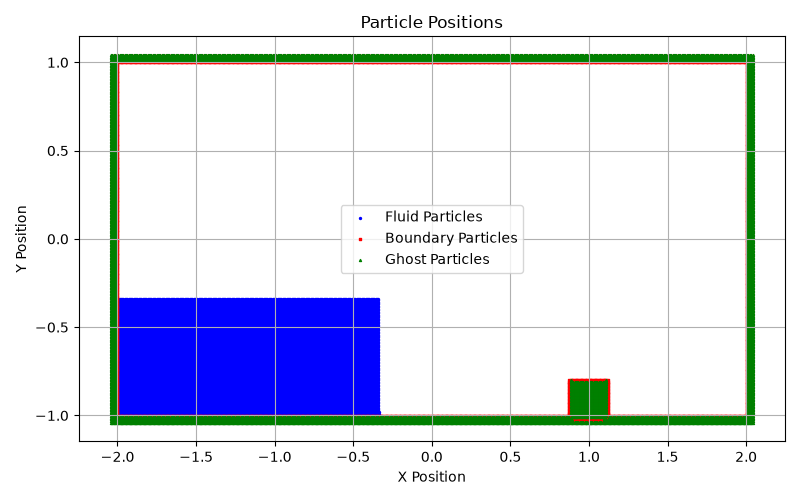

In [14]:
fig, axis = plt.subplots(1,1, figsize=(8, 5), squeeze=False)

axis[0,0].scatter(state.positions[state.kinds == 0, 0].cpu().numpy(), state.positions[state.kinds == 0, 1].cpu().numpy(), c='blue', marker='o', label='Fluid Particles', s = markerSize * 2)
axis[0,0].scatter(state.positions[state.kinds == 1, 0].cpu().numpy(), state.positions[state.kinds == 1, 1].cpu().numpy(), c='red', marker='s', label='Boundary Particles', s = markerSize * 2)
axis[0,0].scatter(state.positions[state.kinds == 2, 0].cpu().numpy(), state.positions[state.kinds == 2, 1].cpu().numpy(), c='green', marker='^', label='Ghost Particles', s = markerSize * 2)

for ax in axis.flatten():
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_title('Particle Positions')
    ax.legend()
    ax.grid(True)

fig.tight_layout()

In [11]:
testDomain = buildDomainDescription(0.5, 2, True, device)
# plotter.updateDomain(testDomain)
plotter.updateQuantities(
        {
            "A": state.UIDs
        },
        newDomain = config.domain,
        newParticleState = state
)


In [17]:
schemeConfig.fluid.fixedSoundSpeed

26.98631979252399

In [18]:
runningState = compressibleSystem.initializeNewState()

In [19]:

markerSize = 8
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B":runningState.state.UIDs
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            plotTitleGap = 0.08,
            boundaryVisualization = VisualizeOptions.Passive,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
            # vMin = 0.0,
            # vMax = schemeConfig.fluid.fixedSoundSpeed * 0.1
        ),
        "B": PlottingOptions(
            colorMap = CyclicColorMap.twilight,
            # flipColorMap=True,
            markerSize = markerSize,
            # midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "UIDs",
            # vMin = 0.95,
            # vMax = 1.05
            plotTitleGap = 0.08,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        )
    },
    figTitle = "Taylor Green Vortex",
    mosaic = 'AB',
    figsize= (14,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)


RFBOutputContext()

In [22]:
integrator = getIntegrator(config.integrationScheme)
config.dim = 2

In [25]:
t_limit = 1.28
nSteps = int(t_limit / config.dt)

runningState = compressibleSystem.initializeNewState()
runningState.adjacency = None
# schemeConfig.rigidBodies[0].linearVelocity = 0.0

kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    t = runningState.t
    # schemeConfig.rigidBodies[0].linearVelocity = 0.5 * torch.cos(t * np.pi * 2)
    # linearVelocity = 0.5 * torch.cos(t * np.pi * 2)

    currentState = runningState.state
    # print(f'-' * 80)
    # print(f'Fluid density stats: min={currentState.densities[currentState.kinds == 0].min().item()}, max={currentState.densities[currentState.kinds == 0].max().item()}, mean={currentState.densities[currentState.kinds == 0].mean().item()}')
    # print(f'Boundary density stats: min={currentState.densities[currentState.kinds == 1].min().item()}, max={currentState.densities[currentState.kinds == 1].max().item()}, mean={currentState.densities[currentState.kinds == 1].mean().item()}')
    if i % 20 == 0 :
        # densities = computeDensities(runningState.state, config, schemeConfig, None)

        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                # "B": runningState.state.densities,
                "B": runningState.state.UIDs
            },
            newParticleState = runningState.state,
        )
        # plotter.export(f'{imagePath}/frame_{i:05d}.png', dpi = 300)
    # break
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break



  0%|          | 0/6400 [00:00<?, ?it/s]

In [15]:
config.kernel

<KernelFunctions.Wendland4: 1>

In [ ]:
print(trajectory.attrs.keys())

In [ ]:
caseName = trajectory.attrs['caseName']
timeLimit = trajectory.attrs['timeLimit']
# dt = trajectory['states']['frame_00001'].attrs['time'] - trajectory['states']['frame_00000'].attrs['time']
nx = trajectory.attrs['nx']
n_h = trajectory.attrs['n_h']
L = trajectory.attrs['L']
W = trajectory.attrs['W']
obstacleType = trajectory.attrs['obstacleType']
aoa = trajectory.attrs['aoa']
obstacleActive = trajectory.attrs['obstacleActive']

dt = loadedConfig['config']['dt']
fixedSoundSpeed = loadedConfig['schemeConfig']['fixedSoundSpeed']

device = torch.device('cpu')
dtype = torch.float32

# dx = loadedConfig['config']['dx']
# band = trajectory.attrs['band']
dim = loadedConfig['config']['dim']
domain = buildDomainDescription(L, dim, True, device, dtype)
domain.min = torch.tensor(loadedConfig['config']['domain']['min'], device=device, dtype=dtype)
domain.max = torch.tensor(loadedConfig['config']['domain']['max'], device=device, dtype=dtype)

In [ ]:
markerSize = 6
plotWidth = 28
plotHeight = 10

In [ ]:
stateIndex = 0
state, time = load_state(stateIndex, trajectory)

caseText = f'{caseName}'
timeText = f't = {time:.4g}/{timeLimit:.4g} | dt = {dt:.4g}'
particleText = f'particles = {len(state.positions[state.kinds == 0])} fluid + {len(state.positions[state.kinds == 1])} boundary | nx = {nx} | n_h = {n_h}'
domainText = f'L = {L}, W = {W}'
obstacleText = f'obstacle: {obstacleType}, aoa: {aoa}' if obstacleActive else 'no obstacle'
stateText = f'v_max = {state.velocities.max().cpu().item():.4g} (c0 = {fixedSoundSpeed:.4g}), rho_max = {state.densities.max().cpu().item():.4g}, rho_min = {state.densities.min().cpu().item():.4g}'
timingText = f'iter time: {0.00:.3f} ms'

titleString = f'{caseText} | {timeText} | {particleText} | {domainText} | {obstacleText} | {stateText} | {timingText}'

from ipywidgets import widgets

def update_frame(frame_index):
    global state, time
    state, time = load_state(frame_index, trajectory)
    plotter.updateQuantities({
        # "A": state.velocities,
        "A": state.UIDs
    }, newParticleState=state)
    caseText = f'{caseName}'
    timeText = f't = {time:.4g}/{timeLimit:.4g} | dt = {dt:.4g}'
    particleText = f'particles = {len(state.positions[state.kinds == 0])} fluid + {len(state.positions[state.kinds == 1])} boundary | nx = {nx} | n_h = {n_h}'
    domainText = f'L = {L}, W = {W}'
    obstacleText = f'obstacle: {obstacleType}, aoa: {aoa}' if obstacleActive else 'no obstacle'
    stateText = f'v_max = {state.velocities.max().cpu().item():.4g} (c0 = {fixedSoundSpeed:.4g}), rho_max = {state.densities.max().cpu().item():.4g}, rho_min = {state.densities.min().cpu().item():.4g}'
    timingText = f'iter time: {0.00:.3f} ms'

    titleString = f'{caseText} | {timeText} | {particleText} | {domainText} | {obstacleText} | {stateText} | {timingText}'

    plotter.updateTitle(titleString)


markerSize = 12
velocityPlot = PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "Particle Velocity Magnitude",
            plotTitleGap = 0.08,
            boundaryVisualization = VisualizeOptions.Visualize,
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            #     streamLines = True,
            # ),

            # vMin=1e-10,
            vMin = 0.0,
            vMax = fixedSoundSpeed * 0.1,
        )
densityPlot = PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "Particle Density",
            # vMin = 0.95,
            # vMax = 1.05,
            plotTitleGap = 0.08,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        )
UIDPlot = PlottingOptions(
            colorMap = CyclicColorMap.twilight,
            # flipColorMap=True,
            markerSize = markerSize,
            # midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = f"Particle IDs ({caseName},  {len(state.positions[state.kinds == 0])} fluid + {len(state.positions[state.kinds == 1])} boundary particles)",
            boundaryVisualization = VisualizeOptions.Passive,
            # vMin = 0.95,
            # vMax = 1.05
            plotTitleGap = 0.08,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        )


In [ ]:

plotter = visualize(
    particleState = state,
    domain = domain,
    quantities = {
        # "A": state.velocities,
        "A": state.UIDs
    },
    plotOptions = {
        # "A": velocityPlot,
        "A": UIDPlot
    },
    figTitle = titleString,
    mosaic = 'A',
    figsize= (plotWidth, plotHeight),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

plotter.updateTitle(titleString)


frame_slider = widgets.IntSlider(
    value=500,
    min=0,
    max=numStates-1,
    step=1,
    description='Frame:',
    continuous_update=True,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='80%')
)

frame_slider.observe(lambda change: update_frame(change['new']), names='value')
# update_frame(frame_slider.value)

export_button = widgets.Button(
    description='Export Current Frame',
    button_style='success',
    tooltip='Export the current frame as an image',
    icon='download'
)
export_button.on_click(lambda b: plotter.export(f'{caseName}_frame_{frame_slider.value:05d}.png'))


display(frame_slider)
display(export_button)


In [ ]:
uMax = torch.linalg.norm(state.velocities, dim=1).max().cpu().item()
dx = state.masses[state.kinds == 0].mean().cpu().item() ** (1.0 / dim)  # approximate particle spacing based on mass and density
cfl = uMax * dt / dx
print(f"Max velocity: {uMax:.4g}, dx: {dx:.4g}, dt: {dt:.4g}, CFL number: {cfl:.4g}")

targetCFL = 1.0
maxDt = targetCFL * dx / uMax
print(f"Target CFL: {targetCFL:.4g}, Max dt for target CFL: {maxDt:.4g}")
dtRatio = dt / maxDt
print(f"dt ratio: {dtRatio:.4g} (dt / maxDt for target CFL)")
print(f'Maximum Coarse Graining Factor: {1/dtRatio:.4g} (1 / dtRatio for target CFL)')